
# Week 2: Disaster Data Sources and Visualization

## Overview
This notebook introduces the major data sources used in disaster management workflows, including SAR, optical imagery, UAV imagery, DEMs, and hydrological data. The focus is on understanding what each data type provides and how it supports different disaster phases.

## Learning Objectives
- Identify major geospatial and environmental data sources used in disaster management
- Understand the difference between SAR, optical, UAV, elevation, and hydrological data
- Visualize disaster-relevant datasets using Python
- Interpret which data sources are best suited for different tasks

## Expected Outcome
By the end of this notebook, you should be able to explain the purpose of common disaster data sources and create basic visualizations from sample datasets.



## Notebook Structure
This notebook is organized into the following sections:

1. Environment setup  
2. Why data matters in disaster management  
3. Common disaster data sources  
4. Synthetic visual examples  
5. Interpretation and comparison  
6. Mini exercise  
7. Weekly assignment  

> This week uses **illustrative synthetic examples** so students can focus on concepts before working with larger real datasets.


In [1]:

# Week 2 setup: imports and environment check

import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Python version:", sys.version.split()[0])
print("Working directory:", os.getcwd())


Python version: 3.12.13
Working directory: /content


In [2]:

# Create a simple output folder for this week's figures

BASE_DIR = Path.cwd()
OUTPUT_DIR = BASE_DIR / "outputs" / "week02"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory ready:", OUTPUT_DIR)


Output directory ready: /content/outputs/week02



## Why Data Matters in Disaster Management

Disaster intelligence depends on the quality, type, and timing of available data. Different stages of disaster management rely on different observations:

- **Preparedness:** risk maps, land use, terrain, drainage, historical flood records
- **Rapid assessment:** live or near-real-time imagery, rainfall, flood extent, road access
- **Post-disaster assessment:** damage mapping, change detection, recovery planning, loss estimation

The most important idea this week is that **no single data source is enough**. In practice, disaster workflows are strongest when they combine multiple sources.



## Common Data Sources

Below is a summary table of key data sources frequently used in flood and disaster workflows.


In [3]:

# Summary table of major disaster data sources

data_sources = pd.DataFrame([
    {
        "Data Source": "SAR Imagery",
        "Type": "Remote sensing",
        "Main Strength": "Works through clouds and at night",
        "Main Limitation": "Harder to interpret visually",
        "Typical Use": "Flood extent and rapid mapping",
        "Disaster Phase": "Preparedness / Rapid assessment"
    },
    {
        "Data Source": "Optical Imagery",
        "Type": "Remote sensing",
        "Main Strength": "Easy to interpret visually",
        "Main Limitation": "Affected by clouds and lighting",
        "Typical Use": "Water detection, damage inspection",
        "Disaster Phase": "Preparedness / Rapid assessment / Post-disaster"
    },
    {
        "Data Source": "UAV / Drone Imagery",
        "Type": "Aerial sensing",
        "Main Strength": "Very high spatial detail",
        "Main Limitation": "Small coverage area and logistics",
        "Typical Use": "Local inspection and emergency support",
        "Disaster Phase": "Rapid assessment / Post-disaster"
    },
    {
        "Data Source": "DEM",
        "Type": "Topographic data",
        "Main Strength": "Represents elevation and terrain flow behavior",
        "Main Limitation": "May not reflect recent surface changes",
        "Typical Use": "Flood susceptibility and runoff modeling",
        "Disaster Phase": "Preparedness"
    },
    {
        "Data Source": "Rainfall Data",
        "Type": "Meteorological",
        "Main Strength": "Captures storm forcing",
        "Main Limitation": "May vary strongly across space",
        "Typical Use": "Forecasting and warning",
        "Disaster Phase": "Preparedness / Rapid assessment"
    },
    {
        "Data Source": "River / Flow Data",
        "Type": "Hydrological",
        "Main Strength": "Tracks water response over time",
        "Main Limitation": "Sensor availability can be limited",
        "Typical Use": "Flood monitoring and hydrograph analysis",
        "Disaster Phase": "Preparedness / Rapid assessment"
    },
    {
        "Data Source": "Crowdsourced / Social Media",
        "Type": "Human-generated",
        "Main Strength": "Fast situational updates",
        "Main Limitation": "Noisy and inconsistent",
        "Typical Use": "Situational awareness",
        "Disaster Phase": "Rapid assessment"
    }
])

data_sources


,Data Source,Type,Main Strength,Main Limitation,Typical Use,Disaster Phase
0,SAR Imagery,Remote sensing,Works through clouds and at night,Harder to interpret visually,Flood extent and rapid mapping,Preparedness / Rapid assessment
1,Optical Imagery,Remote sensing,Easy to interpret visually,Affected by clouds and lighting,"Water detection, damage inspection",Preparedness / Rapid assessment / Post-disaster
2,UAV / Drone Imagery,Aerial sensing,Very high spatial detail,Small coverage area and logistics,Local inspection and emergency support,Rapid assessment / Post-disaster
3,DEM,Topographic data,Represents elevation and terrain flow behavior,May not reflect recent surface changes,Flood susceptibility and runoff modeling,Preparedness
4,Rainfall Data,Meteorological,Captures storm forcing,May vary strongly across space,Forecasting and warning,Preparedness / Rapid assessment
5,River / Flow Data,Hydrological,Tracks water response over time,Sensor availability can be limited,Flood monitoring and hydrograph analysis,Preparedness / Rapid assessment
6,Crowdsourced / Social Media,Human-generated,Fast situational updates,Noisy and inconsistent,Situational awareness,Rapid assessment



## Quick Interpretation

Some simple rules of thumb:

- Use **SAR** when weather and cloud cover make optical imagery unreliable.
- Use **optical imagery** when visual detail is important.
- Use **UAVs** when you need very detailed local inspection.
- Use **DEMs** when terrain and flow pathways matter.
- Use **rainfall and river data** when timing and hydrologic response are important.
- Use **crowdsourced data** to complement sensor-based observations for situational awareness.



## Synthetic Visualization Examples

The following cells generate simple synthetic examples to help interpret common data types. These are **teaching visuals**, not real disaster observations.


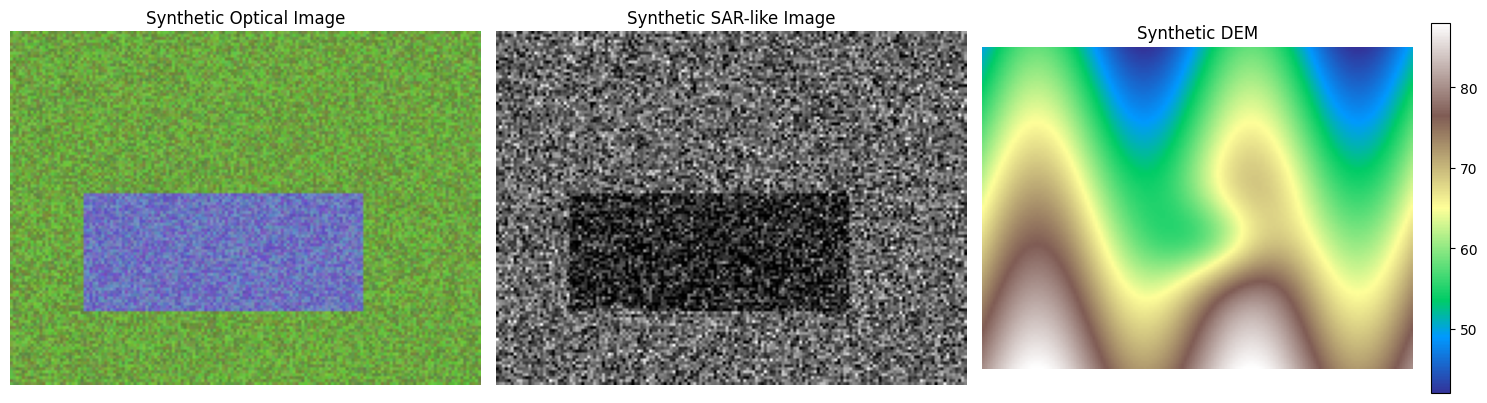

In [4]:

# Create synthetic examples for different disaster data sources

np.random.seed(42)

# Synthetic optical image (RGB-like)
optical = np.zeros((120, 160, 3))
optical[..., 1] = 0.5 + 0.3 * np.random.rand(120, 160)  # vegetation-like green
optical[..., 0] = 0.35 + 0.15 * np.random.rand(120, 160)
optical[..., 2] = 0.2 + 0.1 * np.random.rand(120, 160)

# Add a blue "water" region
optical[55:95, 25:120, 2] += 0.5
optical[55:95, 25:120, 1] -= 0.2
optical = np.clip(optical, 0, 1)

# Synthetic SAR-like image
sar = 0.4 + 0.2 * np.random.randn(120, 160)
sar[55:95, 25:120] -= 0.25  # smoother / darker water-like region
sar = np.clip(sar, 0, 1)

# Synthetic DEM
x = np.linspace(0, 1, 160)
y = np.linspace(0, 1, 120)
xx, yy = np.meshgrid(x, y)
dem = 50 + 30 * yy + 8 * np.sin(4 * np.pi * xx) - 12 * np.exp(-((xx - 0.55)**2 + (yy - 0.6)**2) / 0.02)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(optical)
axes[0].set_title("Synthetic Optical Image")
axes[0].axis("off")

axes[1].imshow(sar, cmap="gray")
axes[1].set_title("Synthetic SAR-like Image")
axes[1].axis("off")

im = axes[2].imshow(dem, cmap="terrain")
axes[2].set_title("Synthetic DEM")
axes[2].axis("off")
fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()



### What to Notice
- In the **optical image**, water is easier to interpret visually.
- In the **SAR-like image**, water can appear distinct even without sunlight.
- In the **DEM**, lower terrain helps explain where water is likely to accumulate or flow.


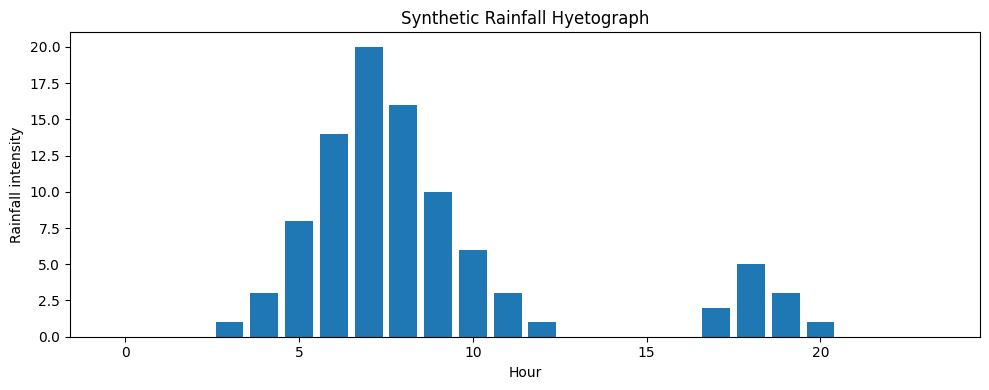

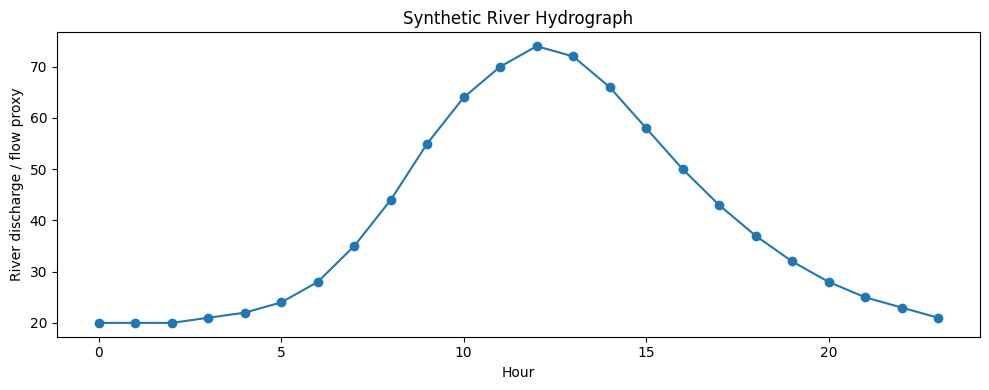

In [5]:

# Synthetic rainfall hyetograph and river hydrograph

hours = np.arange(0, 24)
rainfall = np.array([0, 0, 0, 1, 3, 8, 14, 20, 16, 10, 6, 3, 1, 0, 0, 0, 0, 2, 5, 3, 1, 0, 0, 0], dtype=float)
river_flow = np.array([20, 20, 20, 21, 22, 24, 28, 35, 44, 55, 64, 70, 74, 72, 66, 58, 50, 43, 37, 32, 28, 25, 23, 21], dtype=float)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(hours, rainfall, width=0.8)
ax.set_xlabel("Hour")
ax.set_ylabel("Rainfall intensity")
ax.set_title("Synthetic Rainfall Hyetograph")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hours, river_flow, marker="o")
ax.set_xlabel("Hour")
ax.set_ylabel("River discharge / flow proxy")
ax.set_title("Synthetic River Hydrograph")
plt.tight_layout()
plt.show()



### Interpretation
A **hyetograph** shows rainfall intensity over time, while a **hydrograph** shows how the river or drainage system responds. In real flood workflows, the lag between rainfall and flow response is often important.


In [6]:

# Compare spatial detail, coverage, and weather robustness for key data sources

comparison = pd.DataFrame({
    "Data Source": ["SAR", "Optical", "UAV", "DEM", "Rainfall Stations"],
    "Spatial Detail (1-5)": [3, 4, 5, 3, 2],
    "Coverage (1-5)": [5, 5, 2, 4, 3],
    "Weather Robustness (1-5)": [5, 2, 2, 5, 4]
})

comparison


,Data Source,Spatial Detail (1-5),Coverage (1-5),Weather Robustness (1-5)
0,SAR,3,5,5
1,Optical,4,5,2
2,UAV,5,2,2
3,DEM,3,4,5
4,Rainfall Stations,2,3,4


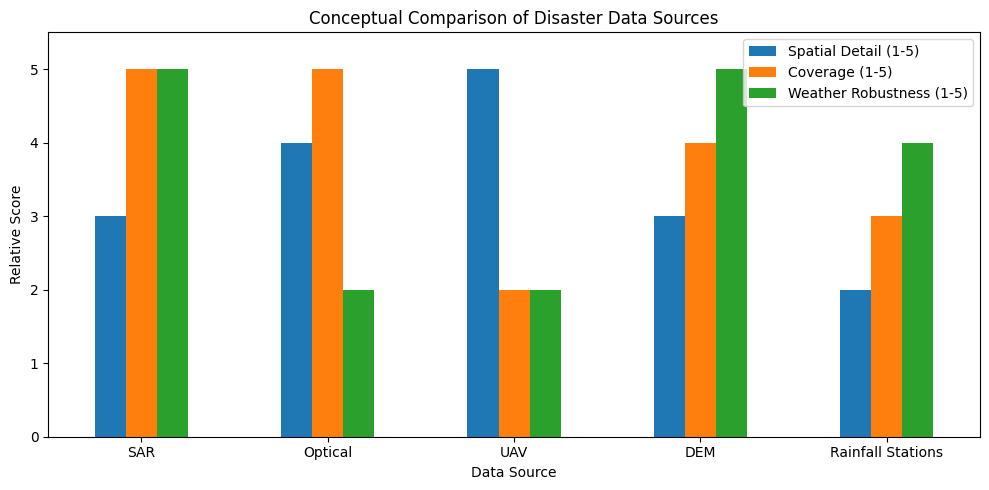

In [7]:

# Visual comparison chart

comparison_plot = comparison.set_index("Data Source")

fig, ax = plt.subplots(figsize=(10, 5))
comparison_plot.plot(kind="bar", ax=ax)
ax.set_title("Conceptual Comparison of Disaster Data Sources")
ax.set_ylabel("Relative Score")
ax.set_ylim(0, 5.5)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



## Mini Exercise

Answer the following in your own words:

1. Why might SAR be preferred over optical imagery during an active storm?
2. Why is a DEM useful even though it is not a real-time data source?
3. In an urban flood scenario, which two data sources would you combine first, and why?

Write your responses in the code cell below as Python comments or in a markdown cell.


In [8]:

# Write your Week 2 mini exercise responses here

# 1.
# 2.
# 3.



## Weekly Assignment

Choose **one disaster scenario** below and describe a practical data strategy:

- Urban flooding
- Wildfire monitoring
- Landslide risk
- Hurricane damage assessment

### Your task
Create a short table with:
- at least **3 data sources**
- the role of each data source
- which disaster phase it supports
- one limitation for each

Then write **one short paragraph** explaining why a multi-source approach is better than using only one dataset.


In [9]:

# Optional assignment starter template

assignment_template = pd.DataFrame({
    "Data Source": ["", "", ""],
    "Role in Workflow": ["", "", ""],
    "Disaster Phase": ["", "", ""],
    "Key Limitation": ["", "", ""]
})

assignment_template


,Data Source,Role in Workflow,Disaster Phase,Key Limitation
0,,,,
1,,,,
2,,,,



## Key Takeaway

The central idea from Week 2 is simple:

> **The value of disaster AI depends heavily on the data behind it.**

Strong disaster workflows do not rely on one source alone. They combine remote sensing, terrain, weather, hydrology, and human observations to support more reliable understanding and better decisions.



## Suggested Extensions
If you want to deepen this notebook later, you can add:
- real Sentinel or Landsat imagery
- sample DEM raster loading with `rasterio`
- simple `geopandas` overlays
- real rainfall CSV plots
- a local flood case study

This keeps the current notebook beginner-friendly while leaving room for future expansion.
